In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import plotly.express as px
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [3]:
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

def linear_model(x, m):
    return m * x

In [4]:
data = pd.read_csv("kinetics_results.csv", sep=";")
data.head(30)

,ID,Protein,SAM Conc,Timepoint,Replicate,FDA Area,SAM Area,Vanillin Area,Dilution,Injection,FDA Corr,SAM Corr,Area SUM,FDA Conc,FDA used,Estimated Rate
0,H191E_400_1_1,H191E,400.00,1,1,0.7827,108.8367,10.3616,1.111111,40,0.020983,2.917736,2.938719,1.601750,0.400437,1.601750
1,H191E_181.82_1_1,H191E,181.82,1,1,0.5340,46.6614,9.3388,1.111111,40,0.015884,1.387919,1.403803,1.212485,0.666860,1.212485
2,H191E_82.65_1_1,H191E,82.65,1,1,0.3682,20.1727,9.1456,1.111111,40,0.011183,0.612702,0.623885,0.853685,1.032892,0.853685
3,H191E_37.57_1_1,H191E,37.57,1,1,0.3564,10.3016,10.2098,1.111111,40,0.009697,0.280275,0.289972,0.740196,1.970178,0.740196
4,H191E_17.08_1_1,H191E,17.08,1,1,0.3036,4.7655,10.5835,1.111111,40,0.007968,0.125077,0.133045,0.608273,3.561318,0.608273
5,H191E_7.76_1_1,H191E,7.76,1,1,0.2106,1.9537,9.5805,1.111111,40,0.006106,0.056646,0.062752,0.466119,6.006682,0.466119
6,H191E_3.53_1_1,H191E,3.53,1,1,0.1317,0.8428,9.3797,1.111111,40,0.003900,0.024959,0.028860,0.297730,8.434286,0.297730
7,H191E_1.6_1_1,H191E,1.60,1,1,0.0734,0.4152,10.0201,1.111111,40,0.002035,0.011510,0.013545,0.155328,9.708010,0.155328
8,H32L_400_1_1,H32L,400.00,1,1,0.6752,97.5850,9.6214,1.111111,40,0.019494,2.817360,2.836853,1.488060,0.372015,1.488060
9,H32L_181.82_1_1,H32L,181.82,1,1,0.8248,54.7525,10.6206,1.111111,40,0.021572,1.432031,1.453603,1.646743,0.905700,1.646743


In [5]:
proteins = data["Protein"].unique()  #["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
substrate = data["SAM Conc"].unique()
timepoints = data["Timepoint"].unique()
replicates = data["Replicate"].unique()

index = pd.MultiIndex.from_product(
    [proteins, substrate, replicates],
    names=["Protein", "SAM Conc", "Replicate"]
)

# Convert to DataFrame
slopes = index.to_frame(index=False)

slopes["v0"] = 0
# slopes["v0_stderr"] = 0
# slopes["R2"] = 0

print(slopes.head())

  Protein  SAM Conc  Replicate  v0
0   H191E    400.00          1   0
1   H191E    400.00          2   0
2   H191E    400.00          3   0
3   H191E    181.82          1   0
4   H191E    181.82          2   0


In [6]:
for prot in proteins:
    for S in substrate: 
        for rep in replicates:
            
            subset = data.loc[(data["Protein"]==prot) & (data["SAM Conc"]==S) & (data["Replicate"]==rep)]   ### Add to exclude values with >20% conversion: & (data["FDA used"]<20)
            
            t_data = np.array(subset["Timepoint"])
            P_data = np.array(subset["FDA Conc"]) 
            
            slope_opt, _ = curve_fit(linear_model, t_data, P_data)
            
            # slope, intercept, r_value, p_value, std_err = linregress(t_data, P_data)
            # print(slope_opt)
            
            slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0"] = slope_opt[0]
            # slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0_stderr"] = std_err
            # slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "R2"] = r_value

slopes.head(30)

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_75195/2075540361.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0680612752769232' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  slopes.loc[(slopes["Protein"]==prot) & (slopes["SAM Conc"]==S) & (slopes["Replicate"]==rep), "v0"] = slope_opt[0]


,Protein,SAM Conc,Replicate,v0
0,H191E,400.00,1,1.068061
1,H191E,400.00,2,1.123681
2,H191E,400.00,3,1.239595
3,H191E,181.82,1,0.876852
4,H191E,181.82,2,0.947990
5,H191E,181.82,3,1.096013
6,H191E,82.65,1,0.579825
7,H191E,82.65,2,0.584849
8,H191E,82.65,3,0.685429
9,H191E,37.57,1,0.408816


In [7]:
index = pd.MultiIndex.from_product(
    [proteins, replicates],
    names=["Protein", "Replicate"]
)

# Convert to DataFrame
kindata = index.to_frame(index=False)

kindata["Vmax"] = 0
kindata["Enzyme_conc_mean"] = [0.967855038, 0.979340973, 0.978944906, 0.965214593, 0.973399972, 0.993071286, 0.997163975, 1.002576887, 0.994919597, 0.956369103, 0.975248283, 0.994391508, 0.979737039, 0.971683683, 0.994787575, 0.978416817, 0.988714552, 0.97802075, 0.977624684, 0.974060083, 1.008517888]
kindata["Enzyme_conc_stdev"] = 0
kindata["kcat"] = 0 
kindata["Km"] = 0


print(kindata.head(100))


   Protein  Replicate  Vmax  Enzyme_conc_mean  Enzyme_conc_stdev  kcat  Km
0    H191E          1     0          0.967855                  0     0   0
1    H191E          2     0          0.979341                  0     0   0
2    H191E          3     0          0.978945                  0     0   0
3     H32L          1     0          0.965215                  0     0   0
4     H32L          2     0          0.973400                  0     0   0
5     H32L          3     0          0.993071                  0     0   0
6     G37D          1     0          0.997164                  0     0   0
7     G37D          2     0          1.002577                  0     0   0
8     G37D          3     0          0.994920                  0     0   0
9       WT          1     0          0.956369                  0     0   0
10      WT          2     0          0.975248                  0     0   0
11      WT          3     0          0.994392                  0     0   0
12   S166A          1    

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_75195/482854132.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2645214914937313' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Vmax"]] = Vmax_fit
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_75195/482854132.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '81.27716969916544' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Km"]] = Km_fit


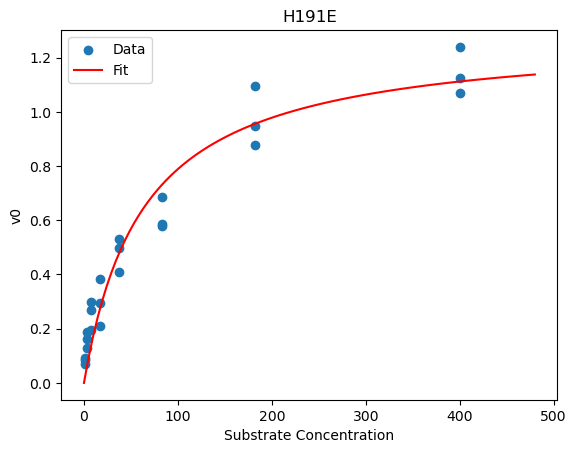

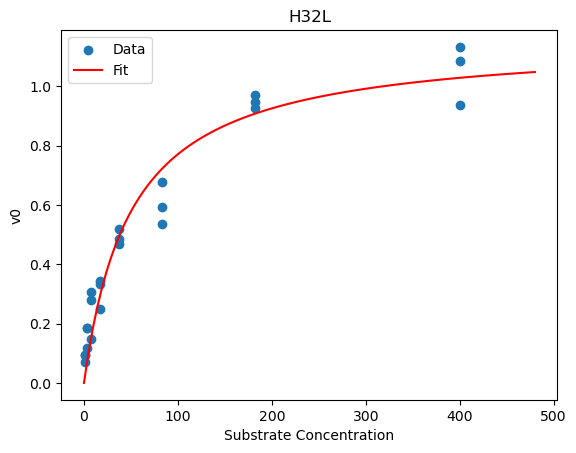

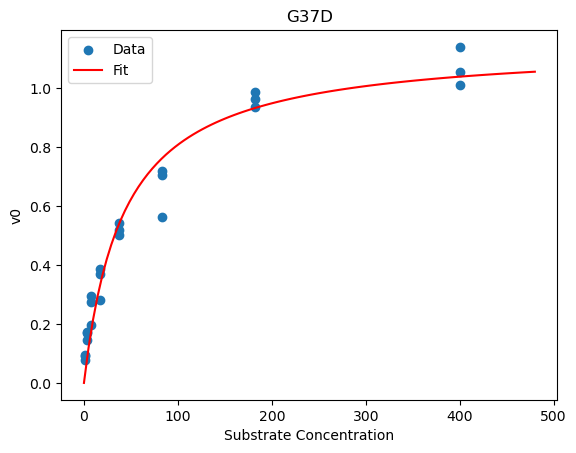

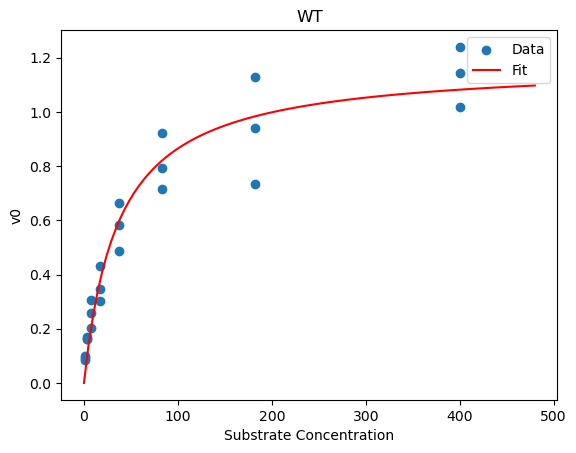

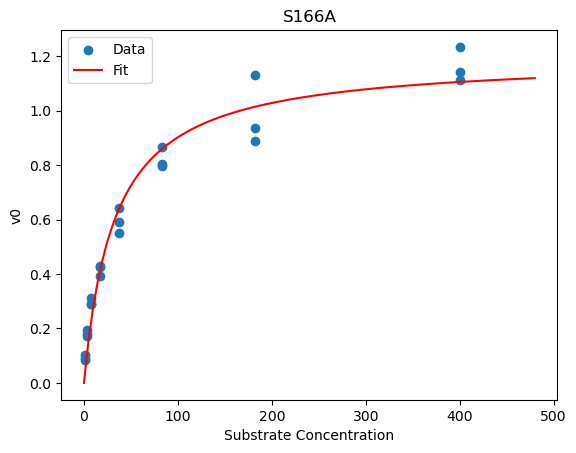

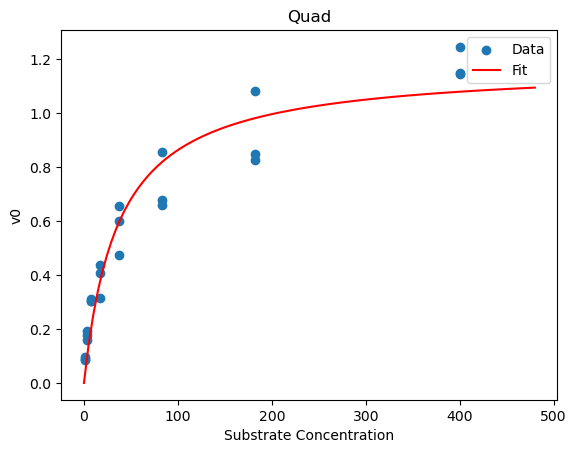

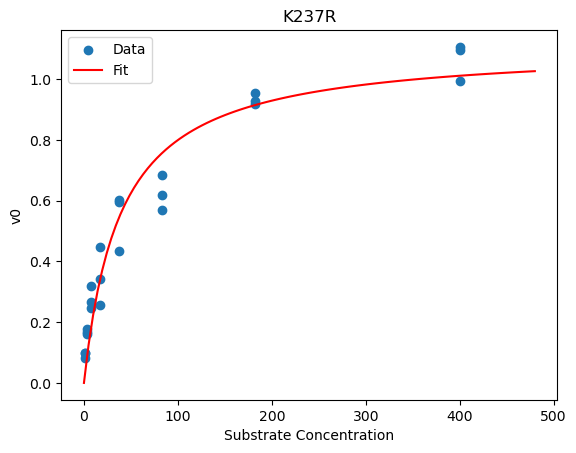

,Protein,Replicate,Vmax,Enzyme_conc_mean,Enzyme_conc_stdev,kcat,Km
0,H191E,1,1.264521,0.967855,0,0.217753,81.277170
1,H191E,2,1.219348,0.979341,0,0.207512,55.319731
2,H191E,3,1.380838,0.978945,0,0.235089,56.268794
3,H32L,1,1.281837,0.965215,0,0.221339,73.494572
4,H32L,2,1.196514,0.973400,0,0.204868,47.589903
5,H32L,3,1.004272,0.993071,0,0.168547,32.884598
6,G37D,1,1.291857,0.997164,0,0.215922,59.085005
7,G37D,2,1.101024,1.002577,0,0.183032,34.324632
8,G37D,3,1.052912,0.994920,0,0.176381,34.252854
9,WT,1,1.327943,0.956369,0,0.231421,33.772095


In [8]:
for prot in proteins: 
    for rep in replicates: 
            
        subset = slopes.loc[(slopes["Protein"]==prot) & (slopes["Replicate"]==rep)]
        
        S_data = np.array(subset["SAM Conc"])
        v_data = np.array(subset["v0"])
        
        popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=[1.2, 30])
        Vmax_fit, Km_fit = popt
        
        
        kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Vmax"]] = Vmax_fit
        kindata.loc[(kindata["Protein"]==prot) & (kindata["Replicate"]==rep), ["Km"]] = Km_fit
            
            
    subset = slopes.loc[(slopes["Protein"]==prot)]
    S_data = np.array(subset["SAM Conc"])
    v_data = np.array(subset["v0"])
    
    popt, pcov = curve_fit(michaelis_menten, S_data, v_data, p0=[1, 1])
    Vmax_fit, Km_fit = popt  

    S_fit = np.linspace(0, max(S_data)*1.2, 100)
    P_fit = michaelis_menten(S_fit, *popt)

    plt.scatter(S_data, v_data, label='Data')
    plt.plot(S_fit, P_fit, color='red', label='Fit')
    plt.title(prot)
    plt.xlabel('Substrate Concentration')
    plt.ylabel('v0')
    plt.legend()
    plt.show()


kindata["kcat"] = kindata["Vmax"]/(kindata["Enzyme_conc_mean"]*6)          
kindata.head(30)


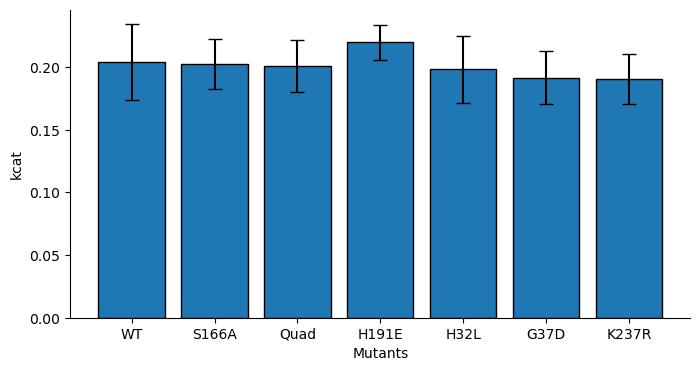

,Protein,mean,std
6,WT,0.203850,0.030378
5,S166A,0.202862,0.019902
4,Quad,0.200795,0.020669
1,H191E,0.220118,0.013940
2,H32L,0.198251,0.027011
0,G37D,0.191779,0.021172
3,K237R,0.190675,0.019895


In [23]:
# Example: Aggregating your data like in the Plotly version
kindata_kcat = kindata.groupby(by=["Protein"])["kcat"].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
kindata_kcat["Protein"] = pd.Categorical(kindata_kcat["Protein"], categories=order, ordered=True)
kindata_kcat = kindata_kcat.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    kindata_kcat["Protein"], 
    kindata_kcat["mean"], 
    yerr=kindata_kcat["std"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0
)

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("kcat")

# Styling background and axes
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', left=True, right=False, direction='out')

plt.show()

kindata_kcat.head(30)


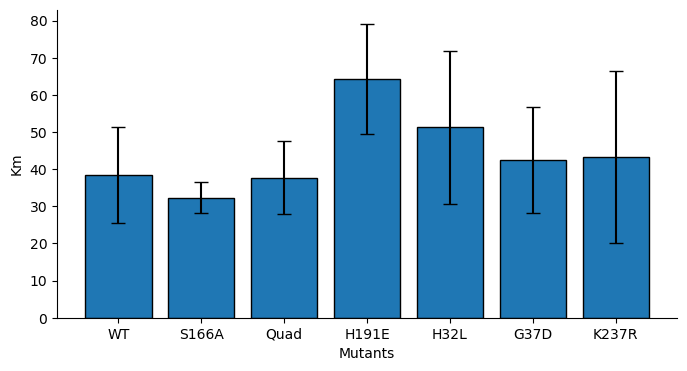

,Protein,mean,std
6,WT,38.491715,12.979276
5,S166A,32.372475,4.239113
4,Quad,37.663995,9.831706
1,H191E,64.288565,14.720214
2,H32L,51.323024,20.560755
0,G37D,42.554164,14.316174
3,K237R,43.286002,23.216156


In [25]:
# Example: Aggregating your data like in the Plotly version
kindata_km = kindata.groupby(by=["Protein"])["Km"].agg(["mean", "std"]).reset_index()

# Order categories
order = ["WT", "S166A", "Quad", "H191E", "H32L", "G37D", "K237R"]
kindata_km["Protein"] = pd.Categorical(kindata_km["Protein"], categories=order, ordered=True)
kindata_km = kindata_km.sort_values("Protein")

# Create bar plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    kindata_km["Protein"], 
    kindata_km["mean"], 
    yerr=kindata_km["std"], 
    capsize=5, 
    edgecolor="black", 
    linewidth=1.0
)

# Labels
ax.set_xlabel("Mutants")
ax.set_ylabel("Km")

# Styling background and axes
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', left=True, right=False, direction='out')

plt.show()

kindata_km.head(30)


In [34]:
kin_colors = {'WT': 'lightgrey',
    'Single': '#FFEFD3',
    'Target': '#516F84',
    'Combi': '#DF9966'}

variant_cat = {'WT':'WT',
    'S166A': 'Single',
                'Quad': 'Combi',
                'H191E': 'Single',
                'H32L': 'Single',
                'G37D': 'Single',
                'K237R': 'Target'}

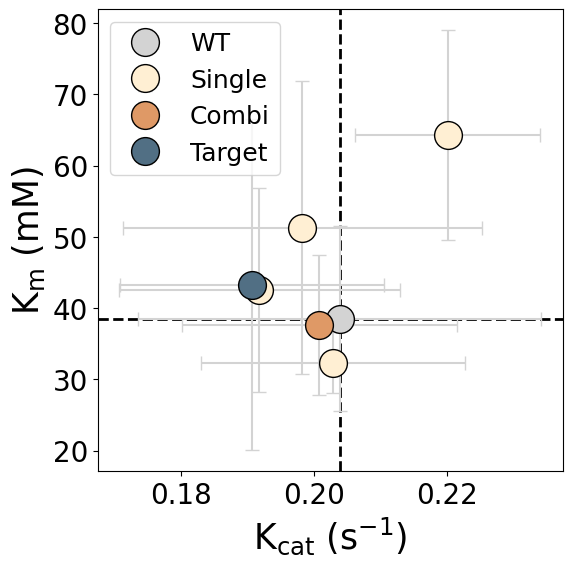

In [38]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axvline(kindata_kcat['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
ax.axhline(kindata_km['mean'].iloc[0], color='black', linewidth=2, linestyle='--',zorder=0)
#ax.scatter(exp_data_full['Kcat'].iloc[0], exp_data_full['Km'].iloc[0], s=200, color='lightgrey', edgecolor='black',zorder=2)
#ax.scatter(exp_data['Kcat'].iloc[0:7], exp_data['Km'].iloc[0:7], s=400, color=mutant_color['Single'], edgecolor='black',zorder=2,label='Rational, Single')
#ax.scatter(exp_data['Kcat'].iloc[7:9], exp_data['Km'].iloc[7:9], s=400, color=mutant_color['Double'], edgecolor='black',zorder=2,label='Rational, Double')
seen_cat = []
for prot in kindata_kcat['Protein']:
    cat = variant_cat[prot]
    ax.errorbar(
        kindata_kcat[kindata_kcat['Protein'] == prot]['mean'],
        kindata_km[kindata_km['Protein'] == prot]['mean'],
        xerr=kindata_kcat[kindata_kcat['Protein'] == prot]['std'],
        yerr=kindata_km[kindata_km['Protein'] == prot]['std'],
        fmt='o',
        color=kin_colors[variant_cat[prot]],
        ecolor='lightgrey',
        markeredgecolor='black',
        capsize=5,
        markersize=20,
        label=cat if cat not in seen_cat else None,
        zorder=2)
    seen_cat.append(cat)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlabel(r'K$_\mathrm{cat}$ (s$^{-1}$)', fontsize=25)
ax.set_ylabel(r'K$_\mathrm{m}$ (mM)', fontsize=25)
ax.legend(fontsize=18, loc='upper left')
plt.savefig('FlA_Kinetics.svg', dpi=300, bbox_inches='tight')
plt.show()